**Dataset:** `data/titanic.csv` (891 passengers). The placement columns of the original notebook are mapped to Titanic columns as described below.

Mapping: `CGPA` → `Pclass`, `Salary Package` → `Fare`, 'placed students with salary > 0' → passengers with `Fare > 0`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [2]:
df = pd.read_csv("/Users/divyasaisomana/placement prediction system/data/titanic.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ------------------------------------------------------------
# Select passengers
# ------------------------------------------------------------
placed_df = df[df["Fare"] > 0].copy()

print("Passengers with Fare > 0:", len(placed_df))



Passengers with Fare > 0: 876


In [4]:
# ------------------------------------------------------------
# Simple Linear Regression
# X = Pclass
# y = Fare
# ------------------------------------------------------------
X = placed_df[["Pclass"]]
y = placed_df["Fare"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (700, 1)
X_test : (176, 1)
y_train: (700,)
y_test : (176,)


In [5]:
#Standardize Pclass for Gradient Descent


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original Pclass:")
print(X_train.head())

print("\nStandardized Pclass:")
print(X_train_scaled[:5])

Original Pclass:
     Pclass
403       3
553       3
530       2
780       3
236       2

Standardized Pclass:
[[ 0.79021199]
 [ 0.79021199]
 [-0.42817654]
 [ 0.79021199]
 [-0.42817654]]


In [6]:
#Batch Gradient Descent from scratch

# Convert to NumPy arrays
X_gd = X_train_scaled.flatten()
y_gd = y_train.to_numpy()

m = len(X_gd)

# Initialize parameters
theta_0 = 0.0
theta_1 = 0.0

learning_rate = 0.01
epochs = 1000

loss_history = []

# ------------------------------------------------------------
# Batch Gradient Descent
# ------------------------------------------------------------
for epoch in range(epochs):

    # Prediction
    y_pred = theta_0 + theta_1 * X_gd
    print(" theta_0:", theta_0)
    print(" theta_1:", theta_1)

    # Error
    error = y_pred - y_gd

    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # Gradients
    gradient_theta_0 = (2 / m) * np.sum(error)
    gradient_theta_1 = (2 / m) * np.sum(error * X_gd)

    # Parameter update
    theta_0 -= learning_rate * gradient_theta_0
    theta_1 -= learning_rate * gradient_theta_1

print("Final theta_0:", theta_0)
print("Final theta_1:", theta_1)
print("Final training MSE:", loss_history[-1])

 theta_0: 0.0
 theta_1: 0.0
 theta_0: 0.6376496314285715
 theta_1: -0.5619516716101848
 theta_0: 1.2625462702285715
 theta_1: -1.1126643097881659
 theta_0: 1.8749449762525714
 theta_1: -1.6523626952025874
 theta_0: 2.4750957081560916
 theta_1: -2.1812671129087207
 theta_0: 3.0632434254215415
 theta_1: -2.6995934422607313
 theta_0: 3.639628188341682
 theta_1: -3.207553245025702
 theta_0: 4.204485256003419
 theta_1: -3.7053538517353726
 theta_0: 4.758045182311922
 theta_1: -4.19319844631085
 theta_0: 5.300533910094255
 theta_1: -4.6712861489948185
 theta_0: 5.832172863320941
 theta_1: -5.139812097625107
 theta_0: 6.353179037483093
 theta_1: -5.59896752728279
 theta_0: 6.863765088162003
 theta_1: -6.0489398483473185
 theta_0: 7.364139417827334
 theta_1: -6.489912722990557
 theta_0: 7.854506260899359
 theta_1: -6.92206614014093
 theta_0: 8.335065767109944
 theta_1: -7.345576488948296
 theta_0: 8.806014083196317
 theta_1: -7.7606166307795155
 theta_0: 9.267543432960961
 theta_1: -8.16735596

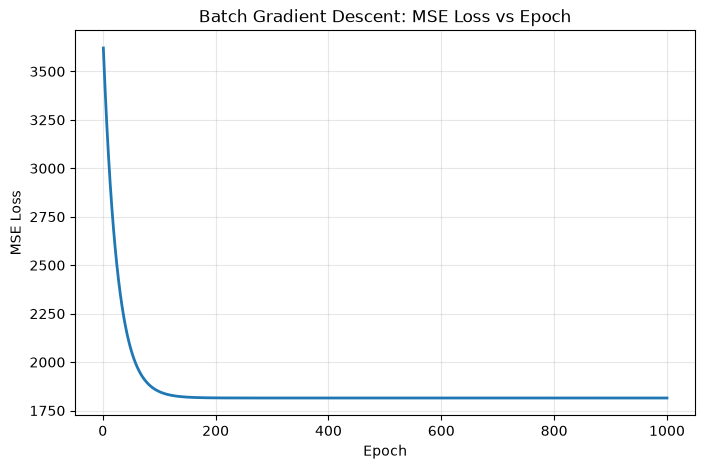

In [7]:
#MSE Curve loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: MSE Loss vs Epoch")
plt.grid(True, alpha=0.3)

plt.show()

In [8]:
X_test_gd = X_test_scaled.flatten()

y_test_pred_gd = theta_0 + theta_1 * X_test_gd

gd_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_gd)
)

gd_mae = mean_absolute_error(
    y_test,
    y_test_pred_gd
)

gd_r2 = r2_score(
    y_test,
    y_test_pred_gd
)

print("Batch GD RMSE:", gd_rmse)
print("Batch GD MAE :", gd_mae)
print("Batch GD R²  :", gd_r2)

Batch GD RMSE: 35.67607253798759
Batch GD MAE : 22.90790016916776
Batch GD R²  : 0.37128762681426175


In [9]:
#Compare with sklearn LinearRegression
sk_model = LinearRegression()

sk_model.fit(
    X_train_scaled,
    y_train
)

y_test_pred_sk = sk_model.predict(
    X_test_scaled
)

sk_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_sk)
)

sk_mae = mean_absolute_error(
    y_test,
    y_test_pred_sk
)

sk_r2 = r2_score(
    y_test,
    y_test_pred_sk
)

print("Sklearn RMSE:", sk_rmse)
print("Sklearn MAE :", sk_mae)
print("Sklearn R²  :", sk_r2)

Sklearn RMSE: 35.67607254468536
Sklearn MAE : 22.90790018977952
Sklearn R²  : 0.3712876265781947


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Batch Gradient Descent",
        "sklearn LinearRegression"
    ],
    "RMSE": [
        gd_rmse,
        sk_rmse
    ],
    "MAE": [
        gd_mae,
        sk_mae
    ],
    "R²": [
        gd_r2,
        sk_r2
    ]
})

display(comparison)

,Model,RMSE,MAE,R²
0,Batch Gradient Descent,35.676073,22.9079,0.371288
1,sklearn LinearRegression,35.676073,22.9079,0.371288


## Using "Mini-Batch Gradient Descent" 

In [11]:
# ------------------------------------------------------------
# Mini-Batch Gradient Descent
# ------------------------------------------------------------

X_mb = X_train_scaled.flatten()
y_mb = y_train.to_numpy()

batch_size = 32
epochs_mb = 1000
learning_rate_mb = 0.01

theta_0_mb = 0.0
theta_1_mb = 0.0

mini_batch_loss = []

rng = np.random.default_rng(42)

n_samples = len(X_mb)

for epoch in range(epochs_mb):

    # Shuffle training data
    indices = rng.permutation(n_samples)

    X_shuffled = X_mb[indices]
    y_shuffled = y_mb[indices]

    # Process mini-batches
    for start in range(0, n_samples, batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        batch_n = len(X_batch)

        # Prediction
        y_batch_pred = (
            theta_0_mb +
            theta_1_mb * X_batch
        )

        # Error
        error = y_batch_pred - y_batch

        # Gradients
        grad_0 = (2 / batch_n) * np.sum(error)

        grad_1 = (
            (2 / batch_n) *
            np.sum(error * X_batch)
        )

        # Update
        theta_0_mb -= learning_rate_mb * grad_0
        theta_1_mb -= learning_rate_mb * grad_1

    # Calculate full training loss after each epoch
    y_epoch_pred = (
        theta_0_mb +
        theta_1_mb * X_mb
    )

    epoch_mse = np.mean(
        (y_epoch_pred - y_mb) ** 2
    )

    mini_batch_loss.append(epoch_mse)

print("Final theta_0:", theta_0_mb)
print("Final theta_1:", theta_1_mb)
print("Final MSE:", mini_batch_loss[-1])

Final theta_0: 31.97132038895798
Final theta_1: -28.142433808291337
Final MSE: 1814.850395200033


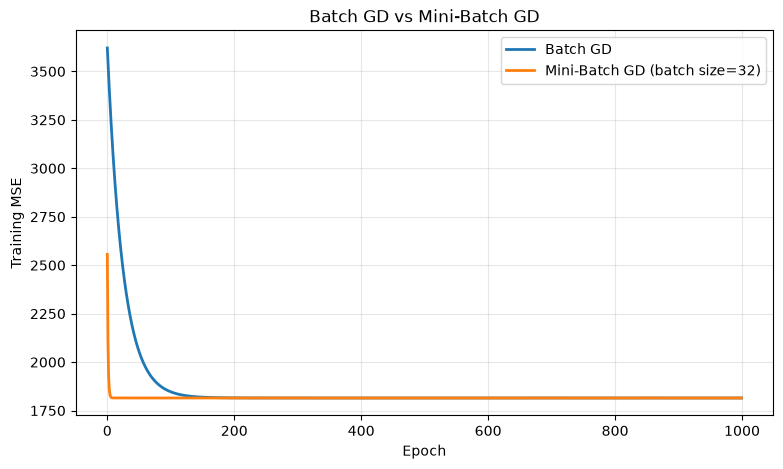

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history,
    label="Batch GD",
    linewidth=2
)

plt.plot(
    mini_batch_loss,
    label="Mini-Batch GD (batch size=32)",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Batch GD vs Mini-Batch GD")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()